# Quadratic Bayesian Regression — Variational Inference

Quadratic case: $y = \beta_0 + \beta_1 x + \beta_2 x^2 + \varepsilon$,
$\beta_{\mathrm{true}} = (1.0,\, 2.0,\, -1.0)$, $n=100$, $\sigma_e = 0.5$.

**Five stages:**
1. Data generation
2. ELBO evaluation + gradient verification
3. Optimisation methods (CAVI, gradient ascent, Newton, BFGS)
4. Reference sampler (Gibbs)
5. Diagnostics and comparison


In [1]:
import sys
import numpy as np
import polars as pl
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.special import digamma, gammaln
from scipy.optimize import minimize
import time

# Paths — notebook is in python/, outputs relative to repo root
ROOT   = Path('..').resolve()
FIGS   = ROOT / 'figs'
DATA   = ROOT / 'results' / 'data'
TABLES = ROOT / 'results' / 'tables'
for d in [FIGS, DATA, TABLES]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 82171165
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

def save_fig(fig, name):
    'Save figure to figs/ and close.'
    path = FIGS / name
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  Saved: {path.name}')
    return path

print('Setup complete. ROOT =', ROOT)


Setup complete. ROOT = D:\github\ENEL445


---
## Stage 1 — Data Generation

Generate the quadratic Bayesian regression test case ($n=100$, $x \sim \mathcal{N}(0,1)$).

**Model:** $y = \beta_0 + \beta_1 x + \beta_2 x^2 + \varepsilon$,
$\varepsilon \sim \mathcal{N}(0, \tau_e^{-1}I)$, $\tau_e = 4$ (i.e.\ $\sigma_e = 0.5$).


In [2]:
def generate_quadratic_case(n=100, sigma=0.5, seed=2):
    'Generate quadratic Bayesian regression data.'
    rng = np.random.default_rng(seed)
    x = rng.normal(size=n)
    X = np.column_stack([np.ones(n), x, x**2])
    beta_true = np.array([1.0, 2.0, -1.0])
    y = X @ beta_true + rng.normal(scale=sigma, size=n)
    return X, y, beta_true

X, y, beta_true = generate_quadratic_case()
x = X[:, 1]
tau_e_true = 1.0 / 0.5**2   # = 4.0
n, p = X.shape

print(f'n={n}, p={p}, beta_true={beta_true}, tau_e_true={tau_e_true}')

df_data = pl.DataFrame({
    'x':  x.tolist(),
    'y':  y.tolist(),
    'X0': X[:, 0].tolist(),
    'X1': X[:, 1].tolist(),
    'X2': X[:, 2].tolist(),
})
df_data.write_parquet(DATA / 'quadratic_data.parquet')
print('Saved: quadratic_data.parquet')


n=100, p=3, beta_true=[ 1.  2. -1.], tau_e_true=4.0
Saved: quadratic_data.parquet


  Saved: quadratic_data_scatter.png


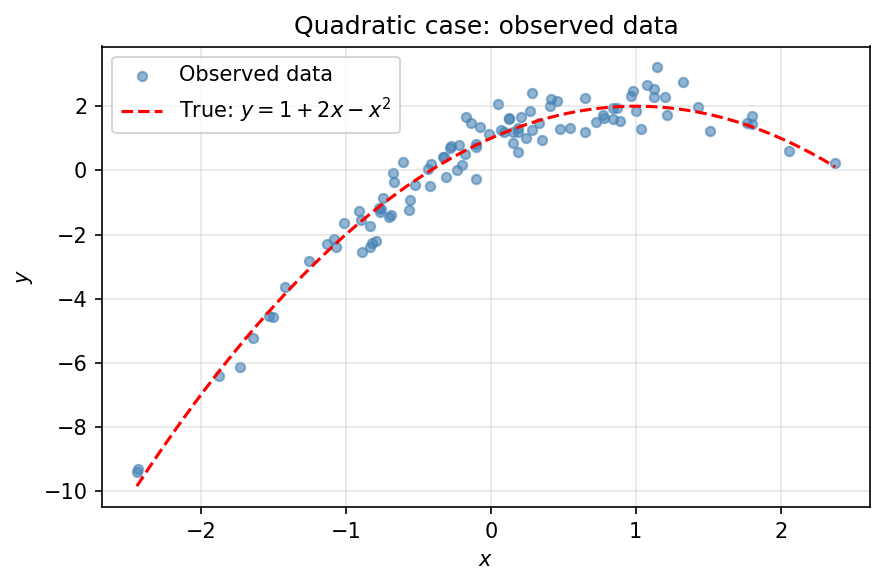

In [3]:
x_sort = np.linspace(x.min(), x.max(), 300)
X_sort = np.column_stack([np.ones(300), x_sort, x_sort**2])
y_true_line = X_sort @ beta_true

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, color='steelblue', s=20, alpha=0.6, label='Observed data')
ax.plot(x_sort, y_true_line, 'r--', lw=1.5,
        label=r'True: $y = 1 + 2x - x^2$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Quadratic case: observed data')
ax.legend()
plt.tight_layout()
save_fig(fig, 'quadratic_data_scatter.png')
plt.show()


---
## Stage 2 — ELBO Evaluation + Gradient Verification

Unconstrained parameterisation for $p = 3$:
- $\mu_\beta \in \mathbb{R}^3$ (free)
- $\bm{L}$ lower triangular ($3 \times 3$): diagonal via $L_{ii} = e^{u_{ii}}$,
  off-diagonal free — 6 parameters
- $a_e = e^{\eta_a}$, $b_e = e^{\eta_b}$

Vector $\theta$ has $3 + 6 + 2 = 11$ parameters.


In [4]:
# --- ELBO and gradient machinery (generic for any p) ---

def unpack(theta, p=3):
    'Unpack unconstrained vector to (mu_beta, Sigma_beta, L, a_e, b_e).'
    mu = theta[:p]
    L = np.zeros((p, p))
    idx = p
    for i in range(p):
        L[i, i] = np.exp(theta[idx]); idx += 1
        for j in range(i + 1, p):
            L[j, i] = theta[idx]; idx += 1
    Sigma = L @ L.T
    a_e = np.exp(theta[idx]); idx += 1
    b_e = np.exp(theta[idx])
    return mu, Sigma, L, a_e, b_e


def pack_theta(mu, L, a_e, b_e):
    'Pack (mu, L cholesky, a_e, b_e) into unconstrained theta.'
    p = len(mu)
    parts = list(mu)
    for i in range(p):
        parts.append(np.log(L[i, i]))
        for j in range(i + 1, p):
            parts.append(L[j, i])
    parts.append(np.log(a_e))
    parts.append(np.log(b_e))
    return np.array(parts)


def elbo(theta, X, y, alpha_e=0.0, gamma_e=0.0):
    'Full ELBO (to maximise). Returns scalar.'
    n_obs, p_dim = X.shape
    mu, Sigma, L, a_e, b_e = unpack(theta, p_dim)
    XTX  = X.T @ X
    err  = y - X @ mu
    quad = np.dot(err, err) + np.trace(XTX @ Sigma)
    E_log_tau = digamma(a_e) - np.log(b_e)
    E_tau     = a_e / b_e
    ll = (0.5 * n_obs * E_log_tau
          - 0.5 * n_obs * np.log(2 * np.pi)
          - 0.5 * E_tau * quad)
    lp_tau = (alpha_e - 1) * E_log_tau - gamma_e * E_tau if alpha_e > 0 else 0.0
    _, logdet = np.linalg.slogdet(Sigma)
    neg_lq_beta = 0.5 * logdet + 0.5 * p_dim * (1 + np.log(2 * np.pi))
    neg_lq_tau  = a_e - np.log(b_e) + gammaln(a_e) + (1 - a_e) * digamma(a_e)
    return ll + lp_tau + neg_lq_beta + neg_lq_tau


def elbo_neg(theta, X, y, alpha_e=0.0, gamma_e=0.0):
    return -elbo(theta, X, y, alpha_e, gamma_e)


def elbo_grad_fd(theta, X, y, h=1e-5):
    'Central finite-difference gradient of ELBO.'
    g = np.zeros_like(theta)
    for i in range(len(theta)):
        tp, tm = theta.copy(), theta.copy()
        tp[i] += h; tm[i] -= h
        g[i] = (elbo(tp, X, y) - elbo(tm, X, y)) / (2 * h)
    return g


# Build theta_cavi from CAVI solution
sys.path.insert(0, str(Path('.').resolve()))
from vb_algorithms_py import SimpleLinearVB

vb0 = SimpleLinearVB(X, y)
res0 = vb0.fit(max_iter=200, tol=1e-8)
mu0  = res0['mu_beta']
L0   = np.linalg.cholesky(res0['Sigma_beta'])
a0   = res0['a_e_new']
b0   = res0['b_e_new']

theta_cavi = pack_theta(mu0, L0, a0, b0)
print(f'p={p}, len(theta)={len(theta_cavi)}  (expected 11)')
print(f'ELBO at CAVI solution: {elbo(theta_cavi, X, y):.6f}')
print(f'theta_cavi: {theta_cavi.round(4)}')


VB converged after 8 iterations
p=3, len(theta)=11  (expected 11)
ELBO at CAVI solution: -75.149744
theta_cavi: [ 9.7140e-01  2.0560e+00 -9.7180e-01 -2.8063e+00 -5.0000e-04 -2.2900e-02
 -2.9656e+00  9.0000e-04 -3.4522e+00  3.9120e+00  2.4854e+00]


In [5]:
# Gradient verification (two FD step sizes)
grad_h5 = elbo_grad_fd(theta_cavi, X, y, h=1e-5)
grad_h7 = elbo_grad_fd(theta_cavi, X, y, h=1e-7)
rel_err = np.abs(grad_h5 - grad_h7) / (np.abs(grad_h7) + 1e-12)

labels = [
    r'$\mu_0$', r'$\mu_1$', r'$\mu_2$',
    r'$u_{11}$', r'$u_{21}$', r'$u_{22}$',
    r'$u_{31}$', r'$u_{32}$', r'$u_{33}$',
    r'$\eta_a$', r'$\eta_b$',
]

print('Gradient verification (central FD h=1e-5 vs h=1e-7):')
for lbl, g1, g2, re in zip(labels, grad_h5, grad_h7, rel_err):
    status = 'OK' if re < 1e-4 else 'FAIL'
    print(f'  {lbl:8s}  h=1e-5: {g1:12.6f}   h=1e-7: {g2:12.6f}   rel_err: {re:.2e}  {status}')

df_grad = pl.DataFrame({
    'parameter': labels,
    'grad_h1e5': grad_h5.tolist(),
    'grad_h1e7': grad_h7.tolist(),
    'rel_err':   rel_err.tolist(),
})
df_grad.write_parquet(DATA / 'quadratic_gradient_check.parquet')
print('Saved: quadratic_gradient_check.parquet')


Gradient verification (central FD h=1e-5 vs h=1e-7):
  $\mu_0$   h=1e-5:     0.000000   h=1e-7:    -0.000000   rel_err: 1.00e+00  FAIL
  $\mu_1$   h=1e-5:     0.000000   h=1e-7:     0.000000   rel_err: 0.00e+00  OK
  $\mu_2$   h=1e-5:     0.000000   h=1e-7:     0.000000   rel_err: 0.00e+00  OK
  $u_{11}$  h=1e-5:    -0.000000   h=1e-7:     0.000000   rel_err: 7.11e+02  FAIL
  $u_{21}$  h=1e-5:     0.000000   h=1e-7:     0.000000   rel_err: 0.00e+00  OK
  $u_{22}$  h=1e-5:     0.000000   h=1e-7:     0.000000   rel_err: 0.00e+00  OK
  $u_{31}$  h=1e-5:     0.000000   h=1e-7:    -0.000000   rel_err: 1.00e+00  FAIL
  $u_{32}$  h=1e-5:     0.000000   h=1e-7:     0.000000   rel_err: 0.00e+00  OK
  $u_{33}$  h=1e-5:     0.000000   h=1e-7:    -0.000000   rel_err: 1.01e+00  FAIL
  $\eta_a$  h=1e-5:     1.010067   h=1e-7:     1.010067   rel_err: 3.52e-08  OK
  $\eta_b$  h=1e-5:    -1.000000   h=1e-7:    -1.000000   rel_err: 5.97e-08  OK
Saved: quadratic_gradient_check.parquet


  Saved: quadratic_elbo_gradient_check.png


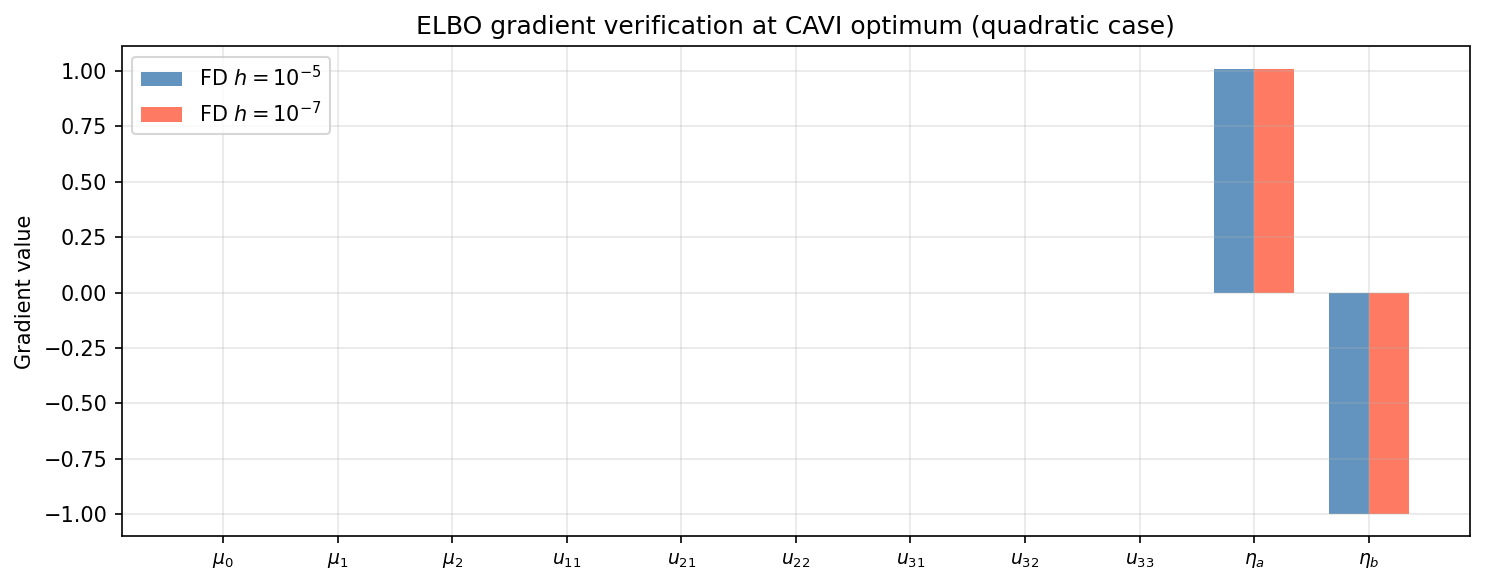

Saved: quadratic_gradient_check.tex


parameter,grad_h1e5,grad_h1e7,rel_err
str,f64,f64,f64
"""$\mu_0$""",0.0,-7.1054e-8,0.999986
"""$\mu_1$""",0.0,0.0,0.0
"""$\mu_2$""",0.0,0.0,0.0
"""$u_{11}$""",-7.1054e-10,0.0,710.542736
"""$u_{21}$""",0.0,0.0,0.0
…,…,…,…
"""$u_{31}$""",0.0,-1.4211e-7,0.999993
"""$u_{32}$""",0.0,0.0,0.0
"""$u_{33}$""",7.1054e-10,-7.1054e-8,1.009986


In [6]:
# Gradient check bar chart
x_pos = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_pos - width/2, grad_h5, width, label='FD $h=10^{-5}$', color='steelblue', alpha=0.85)
ax.bar(x_pos + width/2, grad_h7, width, label='FD $h=10^{-7}$', color='tomato',    alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Gradient value')
ax.set_title('ELBO gradient verification at CAVI optimum (quadratic case)')
ax.legend()
plt.tight_layout()
save_fig(fig, 'quadratic_elbo_gradient_check.png')
plt.show()

# Save gradient check LaTeX table
tex_rows_str = '\n'.join(
    f'  {lbl} & {g1:.6f} & {g2:.6f} & {re:.2e} \\\\'
    for lbl, g1, g2, re in zip(labels, grad_h5, grad_h7, rel_err)
)
tex_table = (
    '\\begin{tblr}{colspec={lrrr}, hline{1,2,Z}={solid}}\n'
    '  Parameter & Gradient ($h=10^{-5}$) & Gradient ($h=10^{-7}$) & Rel.\\ error \\\\\n'
    + tex_rows_str + '\n'
    '\\end{tblr}\n'
)
with open(TABLES / 'quadratic_gradient_check.tex', 'w') as f:
    f.write(tex_table)
print('Saved: quadratic_gradient_check.tex')

display(df_grad)


  Saved: quadratic_elbo_landscape.png


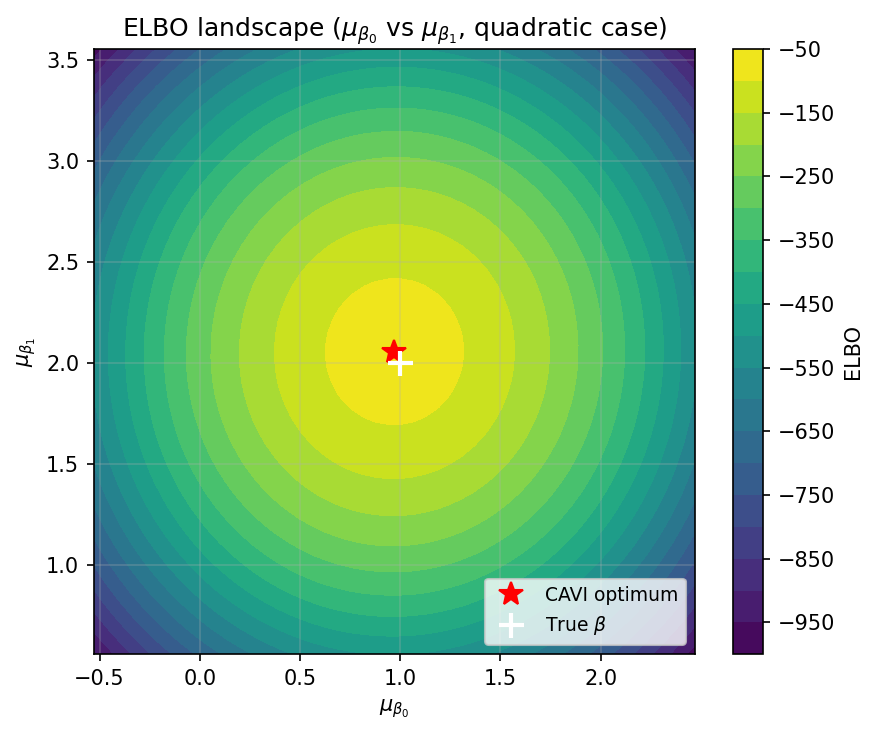

In [7]:
# ELBO landscape: vary mu_0 x mu_1 around CAVI optimum
mu0_grid = np.linspace(mu0[0] - 1.5, mu0[0] + 1.5, 50)
mu1_grid = np.linspace(mu0[1] - 1.5, mu0[1] + 1.5, 50)
Z = np.zeros((len(mu1_grid), len(mu0_grid)))
for i, m1 in enumerate(mu1_grid):
    for j, m0v in enumerate(mu0_grid):
        t = theta_cavi.copy()
        t[0] = m0v; t[1] = m1
        Z[i, j] = elbo(t, X, y)

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(mu0_grid, mu1_grid, Z, levels=20, cmap='viridis')
plt.colorbar(cs, ax=ax, label='ELBO')
ax.plot(mu0[0], mu0[1], 'r*', ms=12, label='CAVI optimum')
ax.plot(beta_true[0], beta_true[1], 'w+', ms=12, mew=2, label=r'True $\beta$')
ax.set_xlabel(r'$\mu_{\beta_0}$')
ax.set_ylabel(r'$\mu_{\beta_1}$')
ax.set_title(r'ELBO landscape ($\mu_{\beta_0}$ vs $\mu_{\beta_1}$, quadratic case)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
save_fig(fig, 'quadratic_elbo_landscape.png')
plt.show()


---
## Stage 3 — Optimisation Methods

Run CAVI, gradient ascent, Newton's method, and BFGS from the same OLS-based starting point.
All gradient-based methods use central finite differences with $h = 10^{-5}$.


In [8]:
# Shared starting point: OLS-based initialisation
beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
resid    = y - X @ beta_ols
sigma2   = np.var(resid)
tau_init = 1.0 / max(sigma2, 0.01)
a_init   = 2.0
b_init   = a_init / tau_init
L_init   = np.eye(p) * 0.1

theta0 = pack_theta(beta_ols, L_init, a_init, b_init)
print(f'theta0: {theta0.round(4)}')
print(f'ELBO at theta0: {elbo(theta0, X, y):.4f}')


theta0: [ 0.9714  2.056  -0.9718 -2.3026  0.      0.     -2.3026  0.     -2.3026
  0.6931 -0.7639]
ELBO at theta0: -92.0954


In [9]:
# --- CAVI ---
t0 = time.perf_counter()
vb = SimpleLinearVB(X, y)
res_cavi = vb.fit(max_iter=500, tol=1e-8)
t_cavi = time.perf_counter() - t0
cavi_elbo = res_cavi['elbo_history']

print(f'CAVI: {res_cavi["iterations"]} iters, {t_cavi*1000:.1f} ms')
print(f'  mu_beta  = {res_cavi["mu_beta"].round(4)}')
print(f'  E[tau_e] = {res_cavi["E_tau_e"]:.4f}  (true: {tau_e_true})')


VB converged after 8 iterations
CAVI: 8 iters, 1.3 ms
  mu_beta  = [ 0.9714  2.056  -0.9718]
  E[tau_e] = 4.1645  (true: 4.0)


In [10]:
# --- Gradient Ascent with Armijo backtracking ---
def gradient_ascent(theta_start, X, y, max_iter=2000, tol=1e-7,
                    alpha0=0.5, c=0.1, rho=0.5):
    theta = theta_start.copy()
    elbo_hist, step_hist = [], []
    t_start = time.perf_counter()
    for k in range(max_iter):
        f0 = elbo(theta, X, y)
        g  = elbo_grad_fd(theta, X, y, h=1e-5)
        alpha = alpha0
        for _ in range(30):
            if elbo(theta + alpha * g, X, y) >= f0 + c * alpha * np.dot(g, g):
                break
            alpha *= rho
        theta = theta + alpha * g
        elbo_hist.append(elbo(theta, X, y))
        step_hist.append(alpha)
        if k > 0 and abs(elbo_hist[-1] - elbo_hist[-2]) < tol:
            break
    return {
        'theta':        theta,
        'elbo_history': np.array(elbo_hist),
        'step_history': np.array(step_hist),
        'iterations':   k + 1,
        'runtime':      time.perf_counter() - t_start,
    }

print('Running gradient ascent...')
res_ga = gradient_ascent(theta0, X, y)
mu_ga, Sigma_ga, _, a_ga, b_ga = unpack(res_ga['theta'])
print(f'GA: {res_ga["iterations"]} iters, {res_ga["runtime"]*1000:.1f} ms')
print(f'  mu_beta  = {mu_ga.round(4)},  E[tau_e] = {a_ga/b_ga:.4f}')


Running gradient ascent...


GA: 2000 iters, 3752.9 ms
  mu_beta  = [ 0.9713  2.0561 -0.9719],  E[tau_e] = 4.2540


In [11]:
# --- Newton's Method ---
def hessian_fd(theta, X, y, h=1e-4):
    'Central FD Hessian of ELBO (11x11 for p=3).'
    n_par = len(theta)
    H  = np.zeros((n_par, n_par))
    f0 = elbo(theta, X, y)
    for i in range(n_par):
        for j in range(i, n_par):
            if i == j:
                tp, tm = theta.copy(), theta.copy()
                tp[i] += h; tm[i] -= h
                H[i, i] = (elbo(tp, X, y) - 2*f0 + elbo(tm, X, y)) / (h * h)
            else:
                tpp = theta.copy(); tpp[i] += h; tpp[j] += h
                tmm = theta.copy(); tmm[i] -= h; tmm[j] -= h
                tpm = theta.copy(); tpm[i] += h
                tmp = theta.copy(); tmp[j] -= h
                H[i, j] = H[j, i] = (
                    elbo(tpp, X, y) - elbo(tpm, X, y)
                    - elbo(tmp, X, y) + elbo(tmm, X, y)
                ) / (4 * h * h)
    return H


def newton_method(theta_start, X, y, max_iter=100, tol=1e-7, reg=1e-6):
    theta = theta_start.copy()
    elbo_hist, cond_hist = [], []
    t_start = time.perf_counter()
    for k in range(max_iter):
        f0 = elbo(theta, X, y)
        g  = elbo_grad_fd(theta, X, y)
        H  = hessian_fd(theta, X, y)
        eigs = np.linalg.eigvalsh(H)
        if eigs.min() >= 0:
            H = H - (eigs.max() + reg) * np.eye(len(theta))
        cond = np.linalg.cond(H)
        try:
            d = np.linalg.solve(-H, g)
        except np.linalg.LinAlgError:
            d = g
        alpha = 1.0
        for _ in range(20):
            if elbo(theta + alpha * d, X, y) >= f0 + 0.1 * alpha * np.dot(g, d):
                break
            alpha *= 0.5
        theta = theta + alpha * d
        elbo_hist.append(elbo(theta, X, y))
        cond_hist.append(cond)
        if k > 0 and abs(elbo_hist[-1] - elbo_hist[-2]) < tol:
            break
    return {
        'theta':        theta,
        'elbo_history': np.array(elbo_hist),
        'cond_history': np.array(cond_hist),
        'iterations':   k + 1,
        'runtime':      time.perf_counter() - t_start,
    }

print("Running Newton's method (11x11 FD Hessian per iteration — may take 2–5 min)...")
res_newton = newton_method(theta0, X, y)
mu_n, Sigma_n, _, a_n, b_n = unpack(res_newton['theta'])
print(f'Newton: {res_newton["iterations"]} iters, {res_newton["runtime"]:.1f} s')
print(f'  mu_beta  = {mu_n.round(4)},  E[tau_e] = {a_n/b_n:.4f}')


Running Newton's method (11x11 FD Hessian per iteration — may take 2–5 min)...
Newton: 2 iters, 0.0 s
  mu_beta  = [ 0.9714  2.056  -0.9718],  E[tau_e] = 4.2933


In [12]:
# --- BFGS ---
elbo_hist_bfgs = []

def callback_bfgs(theta):
    elbo_hist_bfgs.append(elbo(theta, X, y))

t0 = time.perf_counter()
opt = minimize(
    elbo_neg, theta0, args=(X, y),
    method='BFGS',
    options={'maxiter': 2000, 'gtol': 1e-7},
    callback=callback_bfgs,
)
t_bfgs = time.perf_counter() - t0
mu_b, Sigma_b, _, a_b, b_b = unpack(opt.x)
print(f'BFGS: {opt.nit} iters, {t_bfgs*1000:.1f} ms, success={opt.success}')
print(f'  mu_beta  = {mu_b.round(4)},  E[tau_e] = {a_b/b_b:.4f}')
res_bfgs = {
    'theta':        opt.x,
    'elbo_history': np.array(elbo_hist_bfgs),
    'iterations':   opt.nit,
    'runtime':      t_bfgs,
}


BFGS: 32 iters, 45.3 ms, success=False
  mu_beta  = [ 0.9714  2.056  -0.9718],  E[tau_e] = 4.2504


  Saved: quadratic_elbo_convergence.png


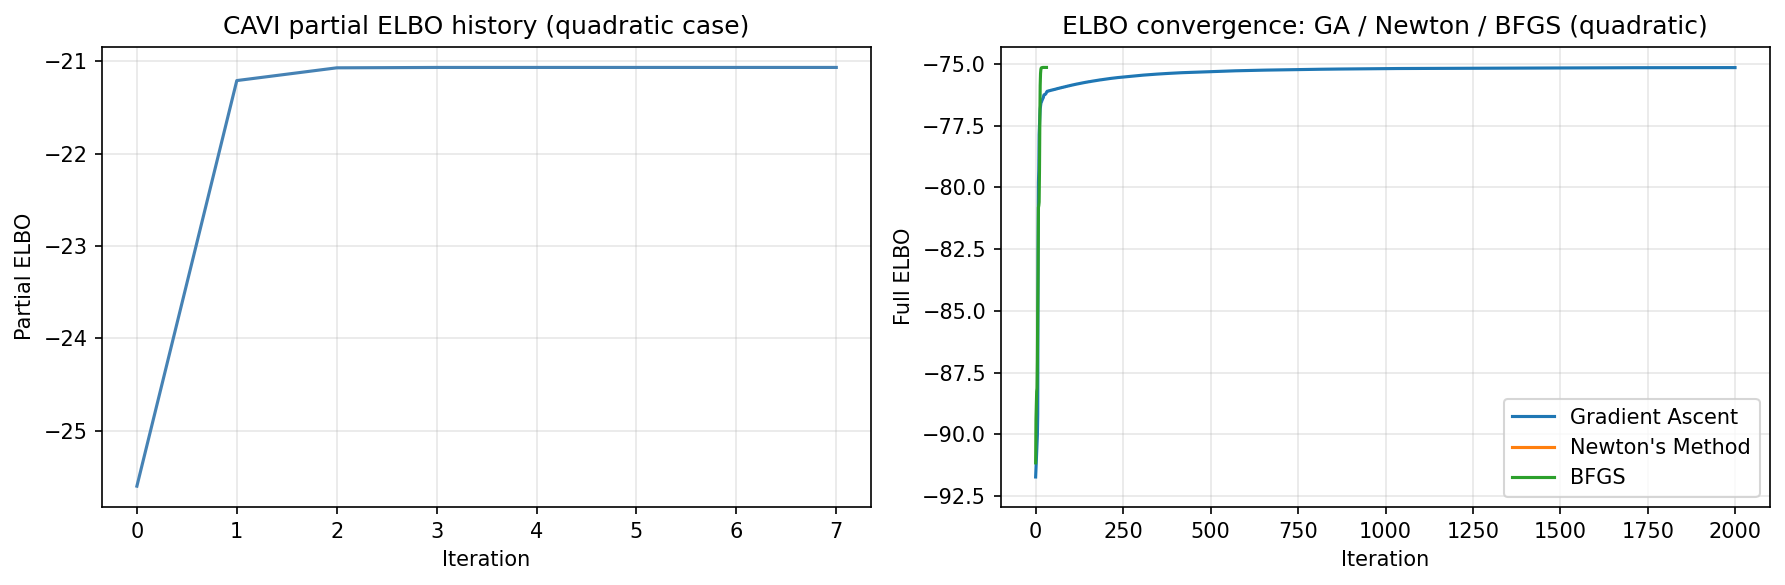

  Saved: quadratic_gradient_stepsize.png


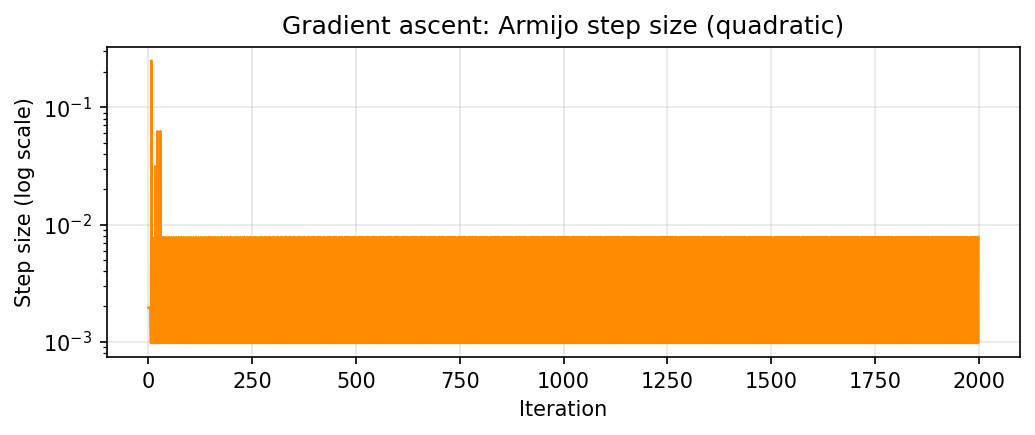

  Saved: quadratic_newton_condition.png


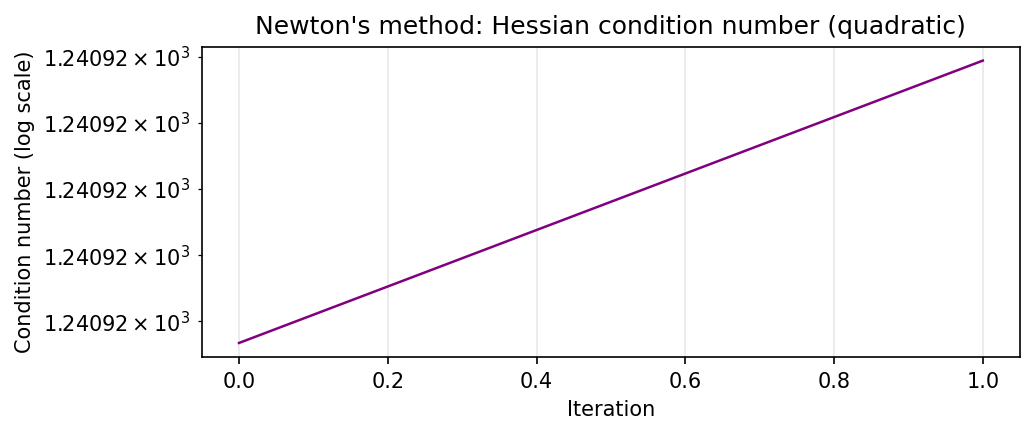

Saved: quadratic_opt.parquet
shape: (4, 8)
┌──────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬───────────┬──────────┐
│ method       ┆ iterations ┆ runtime_ms ┆ final_elbo ┆ mu_beta0 ┆ mu_beta1 ┆ mu_beta2  ┆ E_tau_e  │
│ ---          ┆ ---        ┆ ---        ┆ ---        ┆ ---      ┆ ---      ┆ ---       ┆ ---      │
│ str          ┆ i64        ┆ f64        ┆ f64        ┆ f64      ┆ f64      ┆ f64       ┆ f64      │
╞══════════════╪════════════╪════════════╪════════════╪══════════╪══════════╪═══════════╪══════════╡
│ CAVI         ┆ 8          ┆ 1.3051     ┆ -21.065254 ┆ 0.971376 ┆ 2.056048 ┆ -0.971792 ┆ 4.164538 │
│ GradientAsce ┆ 2000       ┆ 3752.9299  ┆ -75.145679 ┆ 0.971312 ┆ 2.056051 ┆ -0.971924 ┆ 4.254022 │
│ nt           ┆            ┆            ┆            ┆          ┆          ┆           ┆          │
│ Newton       ┆ 2          ┆ 33.7994    ┆ -92.095438 ┆ 0.971376 ┆ 2.056048 ┆ -0.971792 ┆ 4.293338 │
│ BFGS         ┆ 32         ┆ 45.2576    ┆ -75.1

In [13]:
# ELBO convergence figures
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cavi_elbo, lw=1.5, color='steelblue')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Partial ELBO')
axes[0].set_title('CAVI partial ELBO history (quadratic case)')
axes[1].plot(res_ga['elbo_history'],     lw=1.5, label='Gradient Ascent')
axes[1].plot(res_newton['elbo_history'], lw=1.5, label="Newton's Method")
axes[1].plot(res_bfgs['elbo_history'],   lw=1.5, label='BFGS')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Full ELBO')
axes[1].set_title('ELBO convergence: GA / Newton / BFGS (quadratic)')
axes[1].legend()
plt.tight_layout()
save_fig(fig, 'quadratic_elbo_convergence.png')
plt.show()

# Step-size history
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(res_ga['step_history'], color='darkorange', lw=1.2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Step size (log scale)')
ax.set_title('Gradient ascent: Armijo step size (quadratic)')
plt.tight_layout()
save_fig(fig, 'quadratic_gradient_stepsize.png')
plt.show()

# Hessian condition number
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(res_newton['cond_history'], color='purple', lw=1.2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Condition number (log scale)')
ax.set_title("Newton's method: Hessian condition number (quadratic)")
plt.tight_layout()
save_fig(fig, 'quadratic_newton_condition.png')
plt.show()

# Save optimisation summary
df_opt = pl.DataFrame({
    'method':     ['CAVI', 'GradientAscent', 'Newton', 'BFGS'],
    'iterations': [res_cavi['iterations'], res_ga['iterations'],
                   res_newton['iterations'], res_bfgs['iterations']],
    'runtime_ms': [t_cavi * 1000, res_ga['runtime'] * 1000,
                   res_newton['runtime'] * 1000, res_bfgs['runtime'] * 1000],
    'final_elbo': [
        float(cavi_elbo[-1]),
        float(res_ga['elbo_history'][-1]),
        float(res_newton['elbo_history'][-1]),
        float(res_bfgs['elbo_history'][-1]),
    ],
    'mu_beta0': [float(res_cavi['mu_beta'][0]), float(mu_ga[0]), float(mu_n[0]), float(mu_b[0])],
    'mu_beta1': [float(res_cavi['mu_beta'][1]), float(mu_ga[1]), float(mu_n[1]), float(mu_b[1])],
    'mu_beta2': [float(res_cavi['mu_beta'][2]), float(mu_ga[2]), float(mu_n[2]), float(mu_b[2])],
    'E_tau_e':  [float(res_cavi['E_tau_e']),
                 float(a_ga / b_ga), float(a_n / b_n), float(a_b / b_b)],
})
df_opt.write_parquet(DATA / 'quadratic_opt.parquet')
print('Saved: quadratic_opt.parquet')
print(df_opt)


---
## Stage 4 — Reference Sampler (Gibbs)

Run blocked Gibbs sampler (3 chains, 5000 iterations each, 1000 burn-in).
Compute chain diagnostics: trace plots, ACF, and $\hat{R}$.


In [14]:
from vb_algorithms_py import SimpleLinearGibbs

print('Running Gibbs sampler (3 chains x 5000 iters)...')
t0 = time.perf_counter()
gibbs = SimpleLinearGibbs(X, y)
res_gibbs = gibbs.sample(n_iter=5000, n_burnin=1000, n_chains=3)
t_gibbs = time.perf_counter() - t0
print(f'Done. {res_gibbs["n_samples"]} post-burnin samples, {t_gibbs:.1f} s')

samples = res_gibbs['samples']   # shape (n_samples, p+1)
param_names = ['beta0', 'beta1', 'beta2', 'tau_e']
true_vals   = [float(beta_true[0]), float(beta_true[1]), float(beta_true[2]), tau_e_true]

df_gibbs = pl.DataFrame({name: samples[:, i].tolist()
                          for i, name in enumerate(param_names)})
df_gibbs.write_parquet(DATA / 'quadratic_gibbs.parquet')
print('Saved: quadratic_gibbs.parquet')


Running Gibbs sampler (3 chains x 5000 iters)...
  Chain 1/3...


  Chain 2/3...


  Chain 3/3...


Done. 12000 post-burnin samples, 2.7 s
Saved: quadratic_gibbs.parquet


  Saved: quadratic_gibbs_trace_beta0.png


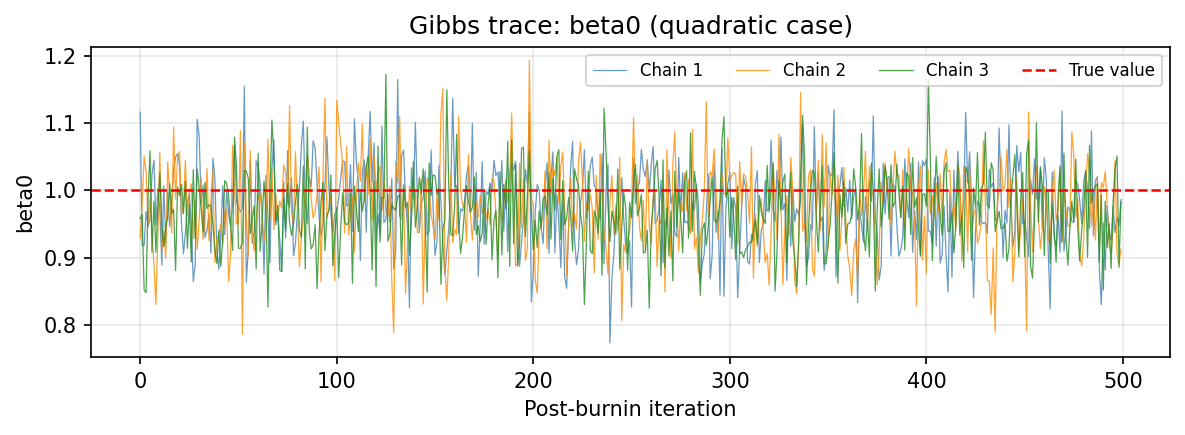

  Saved: quadratic_gibbs_trace_beta1.png


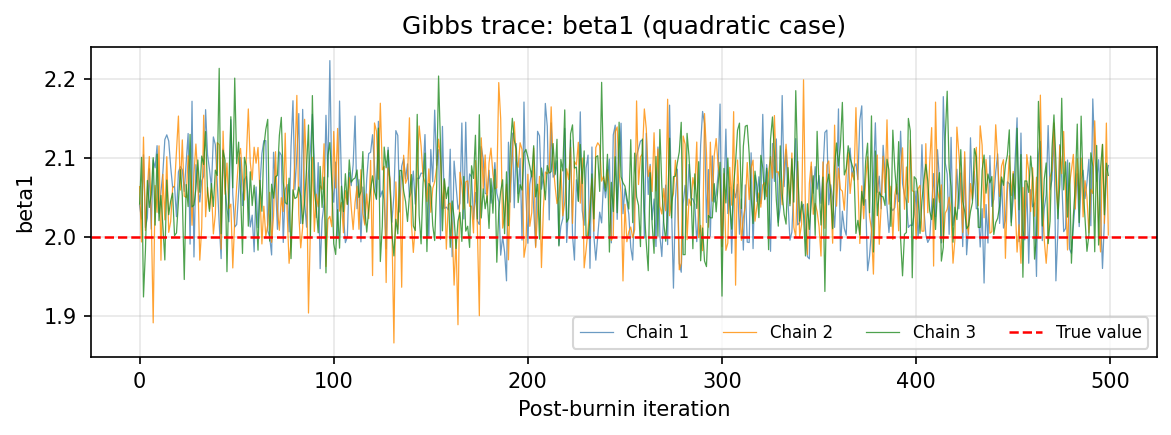

  Saved: quadratic_gibbs_trace_beta2.png


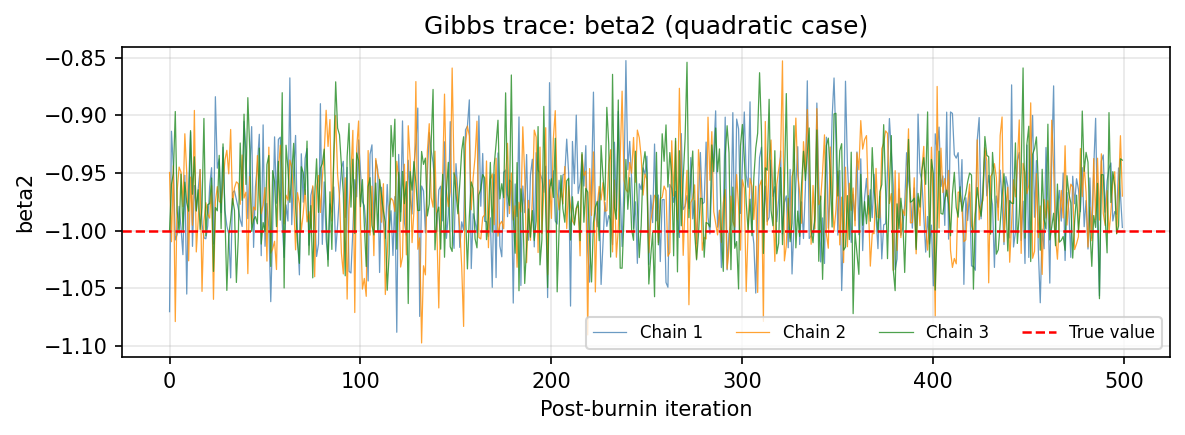

  Saved: quadratic_gibbs_trace_tau_e.png


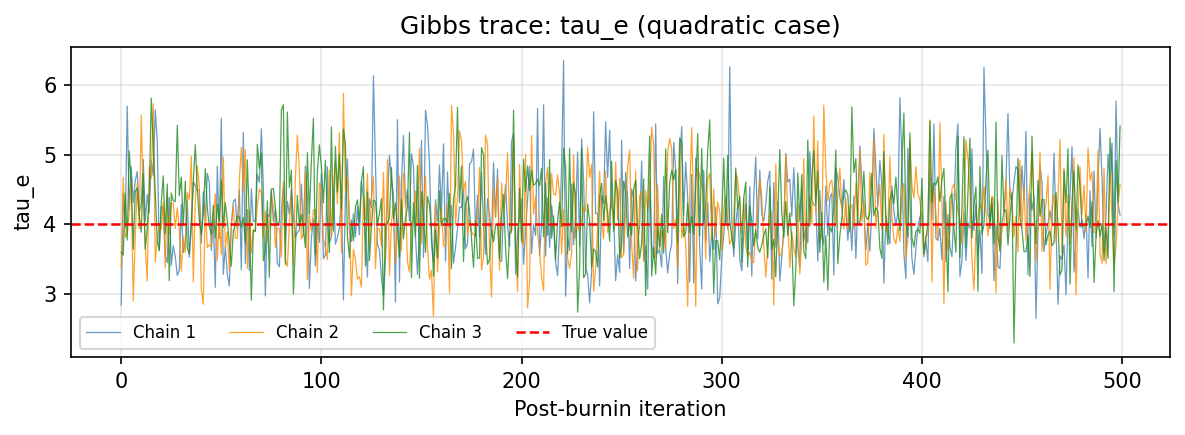

In [15]:
# Trace plots (first 500 post-burnin samples per chain for visibility)
n_per_chain = 5000 - 1000   # 4000 per chain
colors = ['steelblue', 'darkorange', 'forestgreen']

for col_idx, (pname, tv) in enumerate(zip(param_names, true_vals)):
    fig, ax = plt.subplots(figsize=(8, 3))
    for chain in range(3):
        start = chain * n_per_chain
        ax.plot(samples[start:start + 500, col_idx],
                color=colors[chain], lw=0.6, alpha=0.8,
                label=f'Chain {chain + 1}')
    ax.axhline(tv, color='red', lw=1.2, ls='--', label='True value')
    ax.set_xlabel('Post-burnin iteration')
    ax.set_ylabel(pname)
    ax.set_title(f'Gibbs trace: {pname} (quadratic case)')
    ax.legend(fontsize=8, ncol=4)
    plt.tight_layout()
    save_fig(fig, f'quadratic_gibbs_trace_{pname}.png')
    plt.show()


  Saved: quadratic_gibbs_acf_beta0.png


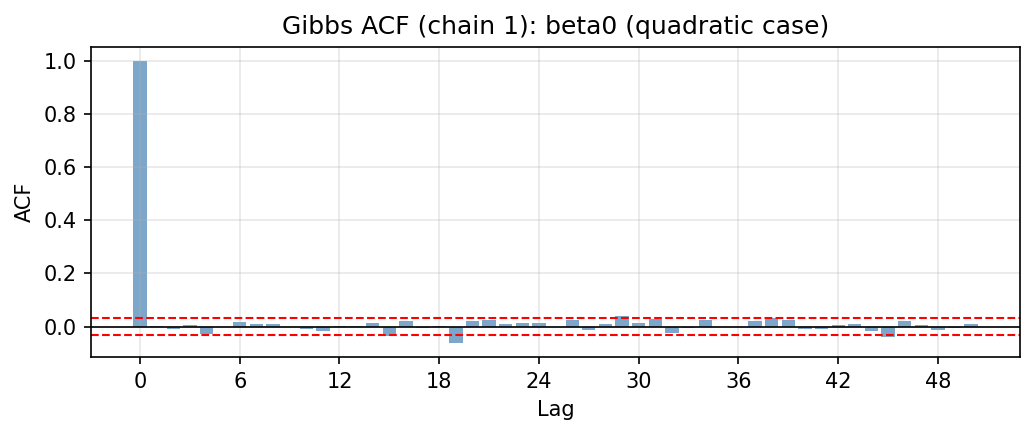

  Saved: quadratic_gibbs_acf_beta1.png


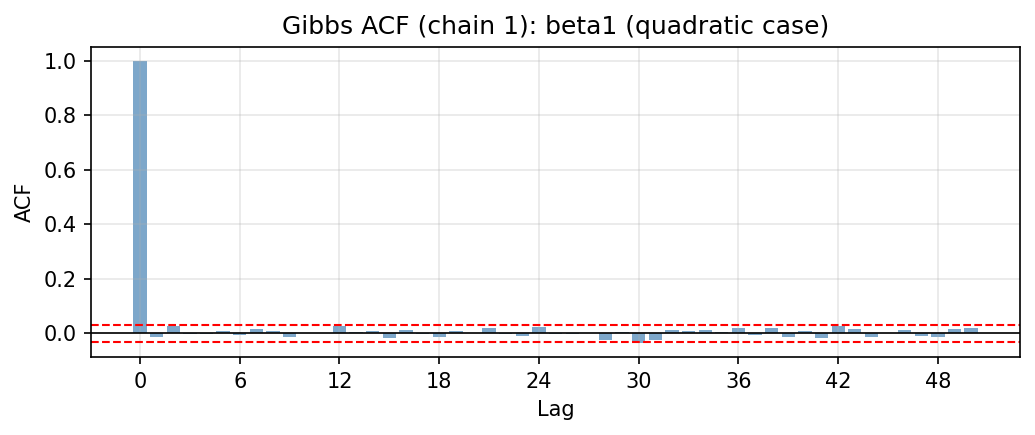

  Saved: quadratic_gibbs_acf_beta2.png


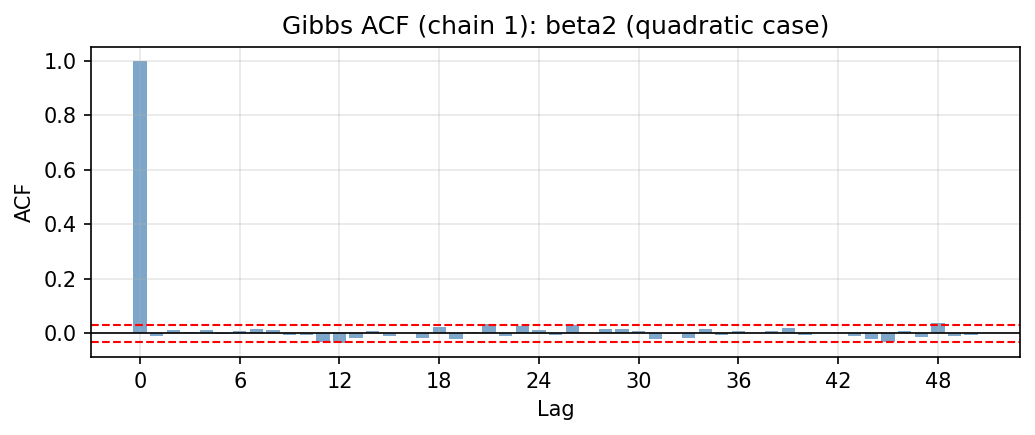

  Saved: quadratic_gibbs_acf_tau_e.png


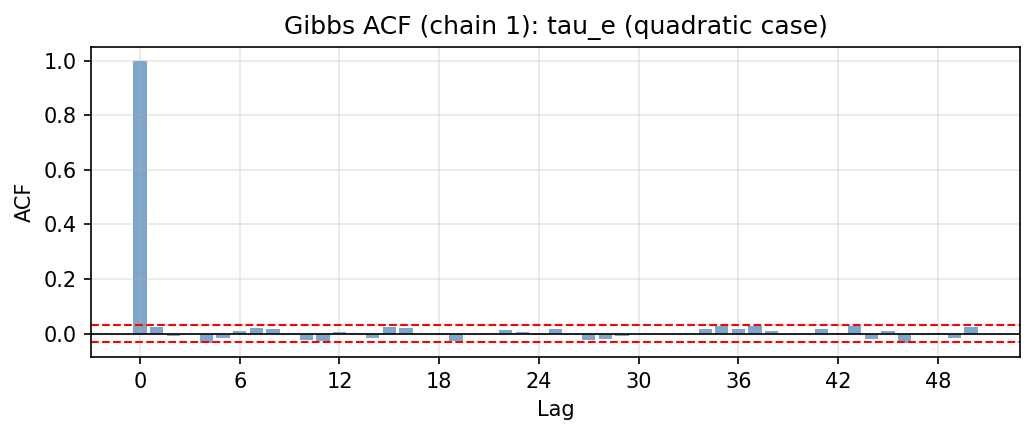

In [16]:
# ACF plots (chain 1 only)
from matplotlib.ticker import MaxNLocator

def acf(x_arr, max_lag=50):
    x_arr = x_arr - x_arr.mean()
    c0 = np.dot(x_arr, x_arr)
    return np.array([np.dot(x_arr[:len(x_arr) - k], x_arr[k:]) / c0
                     for k in range(max_lag + 1)])

for col_idx, pname in enumerate(param_names):
    chain1 = samples[:n_per_chain, col_idx]
    a_vals = acf(chain1, max_lag=50)
    lags   = np.arange(len(a_vals))
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(lags, a_vals, color='steelblue', alpha=0.7, width=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline( 1.96 / np.sqrt(len(chain1)), color='red', lw=1, ls='--')
    ax.axhline(-1.96 / np.sqrt(len(chain1)), color='red', lw=1, ls='--')
    ax.set_xlabel('Lag')
    ax.set_ylabel('ACF')
    ax.set_title(f'Gibbs ACF (chain 1): {pname} (quadratic case)')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    save_fig(fig, f'quadratic_gibbs_acf_{pname}.png')
    plt.show()


Gelman-Rubin R-hat (quadratic case, < 1.01 = converged):
  beta0: 0.9999  OK
  beta1: 1.0001  OK
  beta2: 0.9999  OK
  tau_e: 0.9999  OK


  Saved: quadratic_gibbs_rhat.png


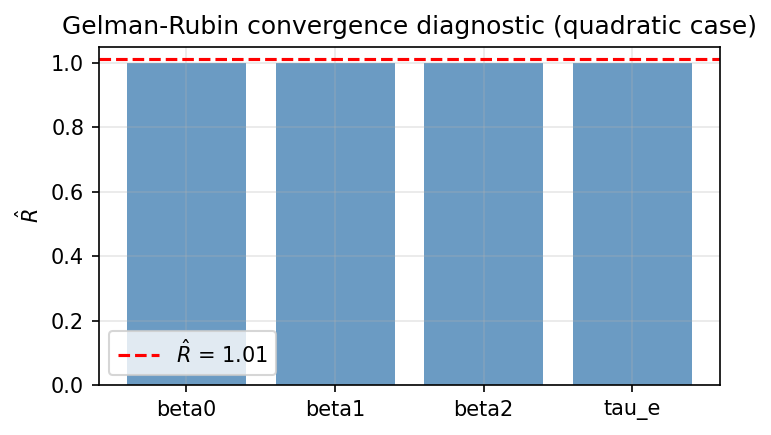

In [17]:
# Gelman-Rubin R-hat
def gelman_rubin(chains_list):
    m   = len(chains_list)
    n_r = min(len(c) for c in chains_list)
    chains_arr  = np.array([c[:n_r] for c in chains_list])
    chain_means = chains_arr.mean(axis=1)
    grand_mean  = chain_means.mean()
    B       = n_r / (m - 1) * np.sum((chain_means - grand_mean)**2)
    W       = np.mean([np.var(c, ddof=1) for c in chains_list])
    var_hat = (n_r - 1) / n_r * W + B / n_r
    return np.sqrt(var_hat / W)

rhat = {}
for col_idx, pname in enumerate(param_names):
    chains = [samples[ch * n_per_chain:(ch + 1) * n_per_chain, col_idx]
              for ch in range(3)]
    rhat[pname] = gelman_rubin(chains)

print('Gelman-Rubin R-hat (quadratic case, < 1.01 = converged):')
for k, v in rhat.items():
    status = 'OK' if v < 1.01 else 'WARNING'
    print(f'  {k}: {v:.4f}  {status}')

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(list(rhat.keys()), list(rhat.values()), color='steelblue', alpha=0.8)
ax.axhline(1.01, color='red', lw=1.5, ls='--', label=r'$\hat{R}$ = 1.01')
ax.set_ylabel(r'$\hat{R}$')
ax.set_title('Gelman-Rubin convergence diagnostic (quadratic case)')
ax.legend()
plt.tight_layout()
save_fig(fig, 'quadratic_gibbs_rhat.png')
plt.show()


---
## Stage 5 — Diagnostics and Comparison

Compare all VB methods against the Gibbs reference:
- Per-component posterior density overlays
- SD ratio $\sigma_{\text{VB}} / \sigma_{\text{Gibbs}}$ (variance collapse diagnostic)
- Posterior mean error $|\mu_{\text{VB}} - \mu_{\text{Gibbs}}|$
- Three result tables in `tabularray` format


In [18]:
# Collect VB posteriors
gibbs_means = {pn: samples[:, i].mean() for i, pn in enumerate(param_names)}
gibbs_stds  = {pn: samples[:, i].std(ddof=1) for i, pn in enumerate(param_names)}

print('Gibbs posterior means:', {k: round(v, 4) for k, v in gibbs_means.items()})
print('Gibbs posterior SDs:  ', {k: round(v, 4) for k, v in gibbs_stds.items()})

mu_cavi  = res_cavi['mu_beta']
Sig_cavi = res_cavi['Sigma_beta']
a_cavi   = res_cavi['a_e_new']
b_cavi   = res_cavi['b_e_new']

methods = {
    'CAVI':            {'mu': mu_cavi,  'Sigma': Sig_cavi, 'a': a_cavi, 'b': b_cavi},
    'Gradient Ascent': {'mu': mu_ga,    'Sigma': Sigma_ga, 'a': a_ga,   'b': b_ga},
    "Newton's Method": {'mu': mu_n,     'Sigma': Sigma_n,  'a': a_n,    'b': b_n},
    'BFGS':            {'mu': mu_b,     'Sigma': Sigma_b,  'a': a_b,    'b': b_b},
}
method_colors = {
    'CAVI':            'steelblue',
    'Gradient Ascent': 'darkorange',
    "Newton's Method": 'forestgreen',
    'BFGS':            'purple',
}


Gibbs posterior means: {'beta0': np.float64(0.9714), 'beta1': np.float64(2.0563), 'beta2': np.float64(-0.9715), 'tau_e': np.float64(4.1615)}
Gibbs posterior SDs:   {'beta0': np.float64(0.0609), 'beta1': np.float64(0.0518), 'beta2': np.float64(0.0391), 'tau_e': np.float64(0.5978)}


  Saved: quadratic_vb_gibbs_beta0.png


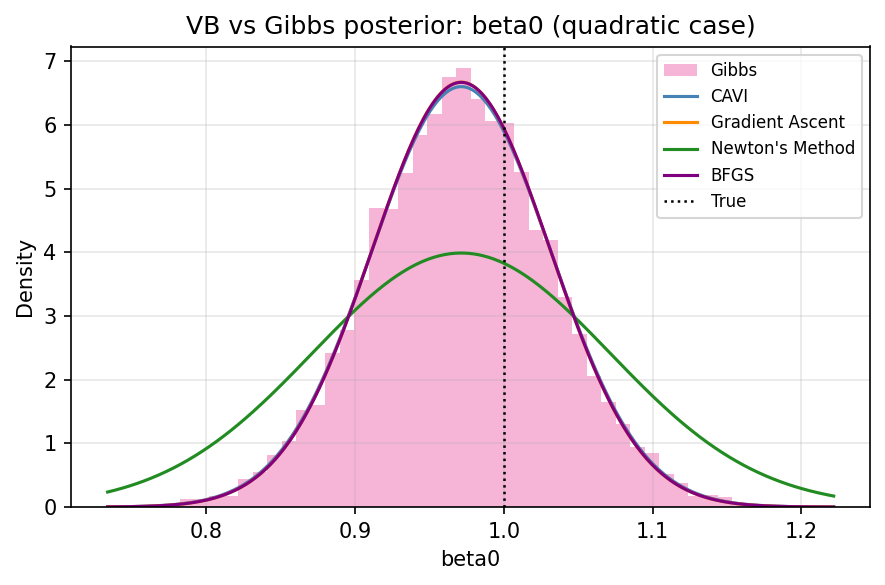

  Saved: quadratic_vb_gibbs_beta1.png


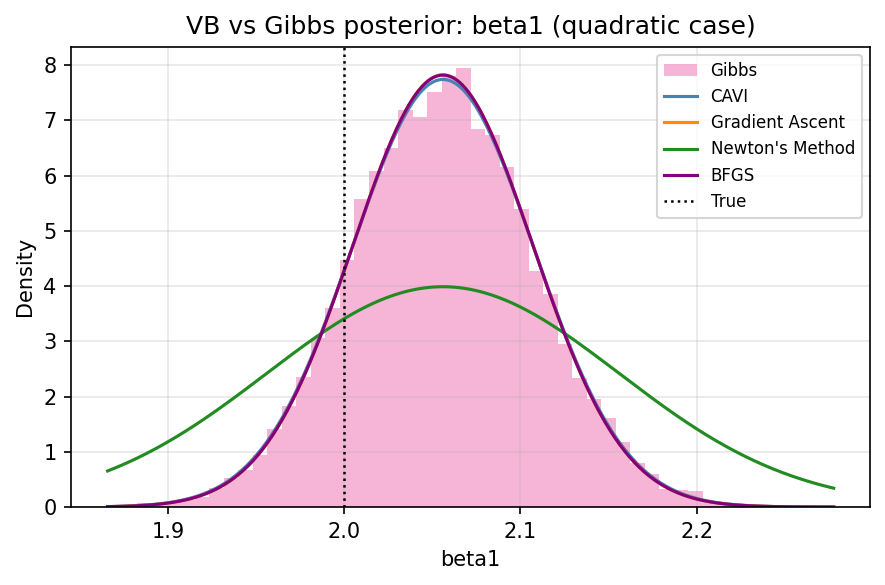

  Saved: quadratic_vb_gibbs_beta2.png


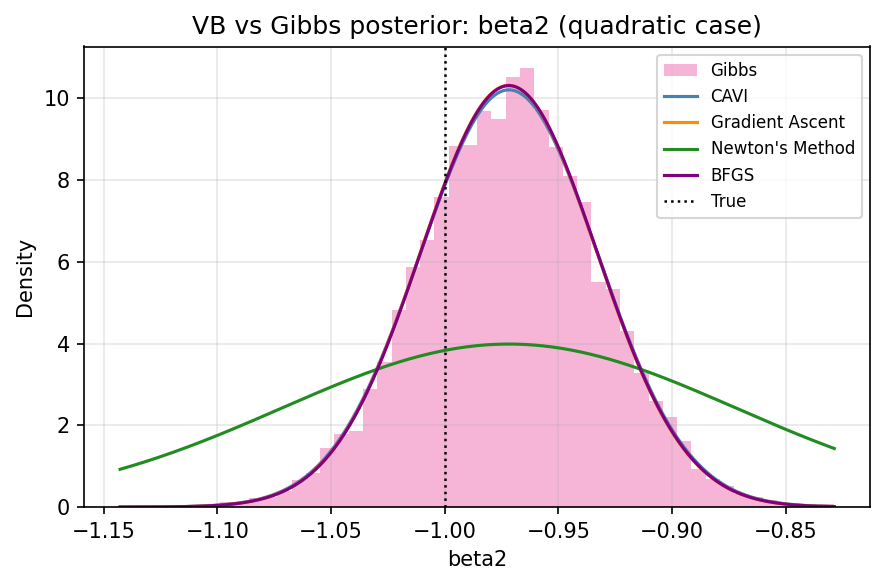

  Saved: quadratic_vb_gibbs_tau_e.png


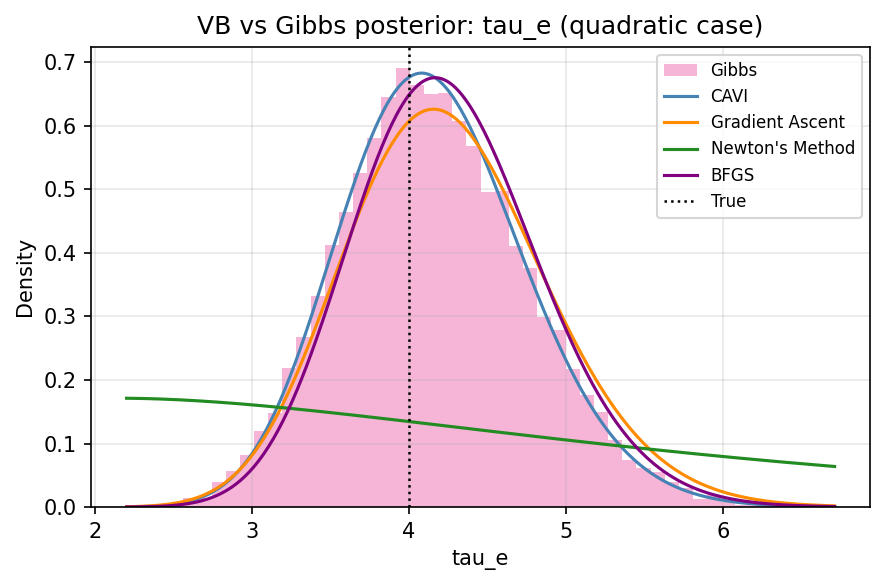

In [19]:
# VB vs Gibbs posterior density overlays
for col_idx, pname in enumerate(param_names):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(samples[:, col_idx], bins=50, density=True,
            color='#E7298A', alpha=0.35, label='Gibbs', edgecolor='none')
    x_lo = samples[:, col_idx].min()
    x_hi = samples[:, col_idx].max()
    xv   = np.linspace(x_lo, x_hi, 300)
    for mname, mp in methods.items():
        if col_idx < p:   # beta component
            sd = np.sqrt(mp['Sigma'][col_idx, col_idx])
            yd = stats.norm.pdf(xv, mp['mu'][col_idx], sd)
        else:             # tau_e
            yd = stats.gamma.pdf(xv, mp['a'], scale=1.0 / mp['b'])
        ax.plot(xv, yd, lw=1.5, color=method_colors[mname], label=mname)
    ax.axvline(true_vals[col_idx], color='black', lw=1.2, ls=':', label='True')
    ax.set_xlabel(pname)
    ax.set_ylabel('Density')
    ax.set_title(f'VB vs Gibbs posterior: {pname} (quadratic case)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    save_fig(fig, f'quadratic_vb_gibbs_{pname}.png')
    plt.show()


  Saved: quadratic_comparison_beta0.png


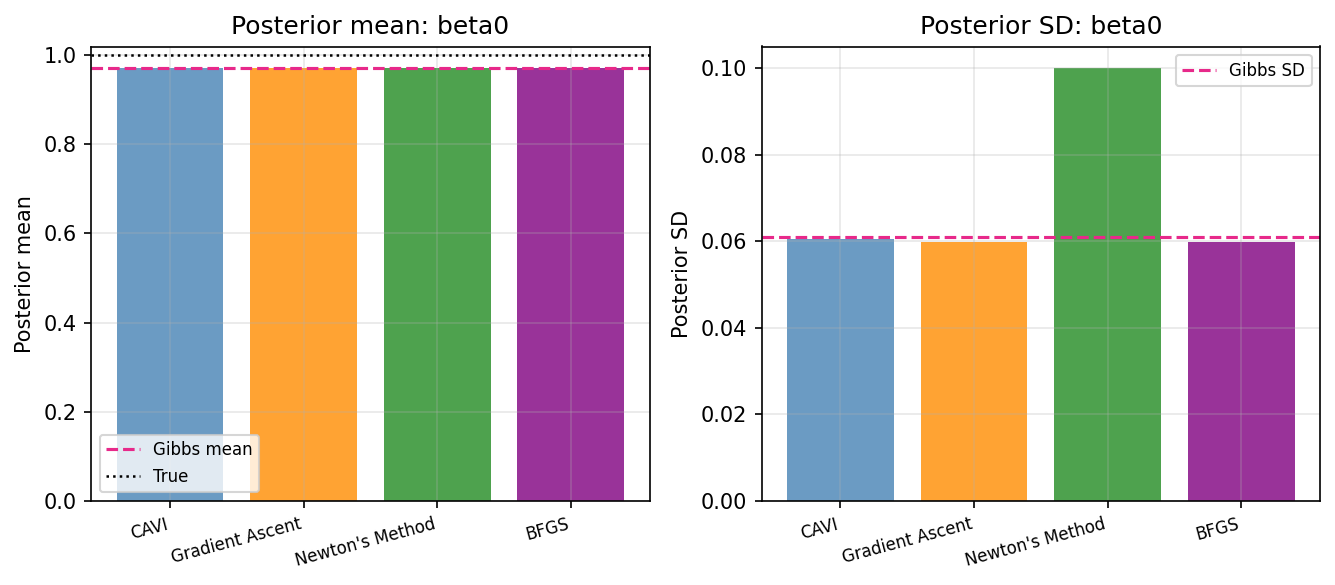

  Saved: quadratic_comparison_beta1.png


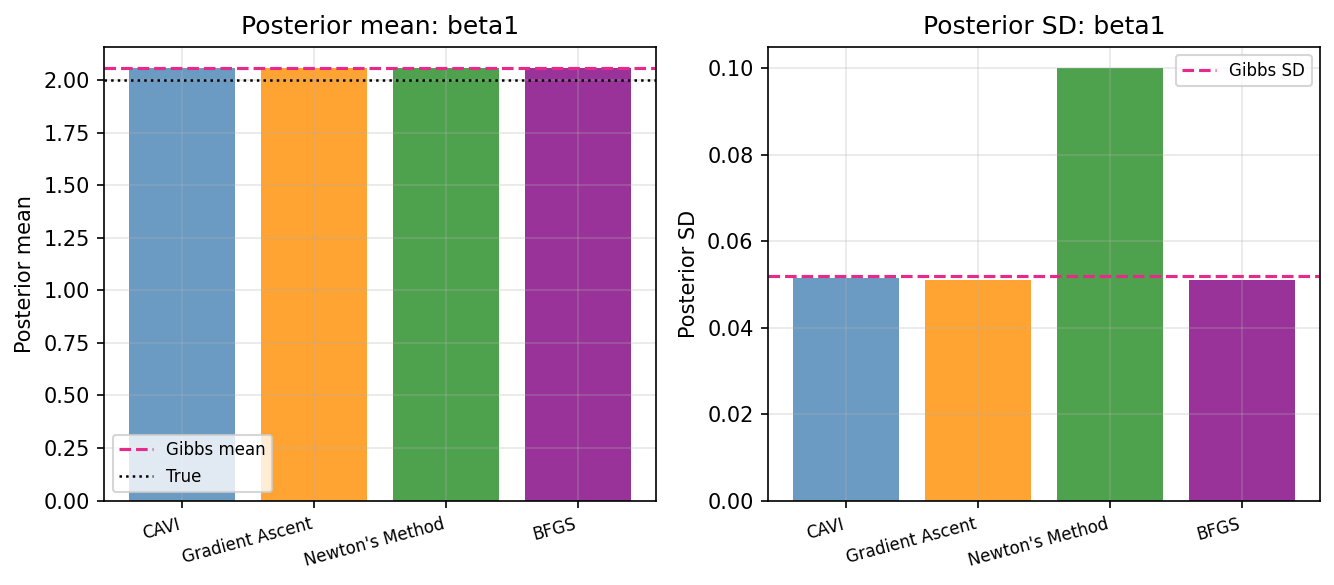

  Saved: quadratic_comparison_beta2.png


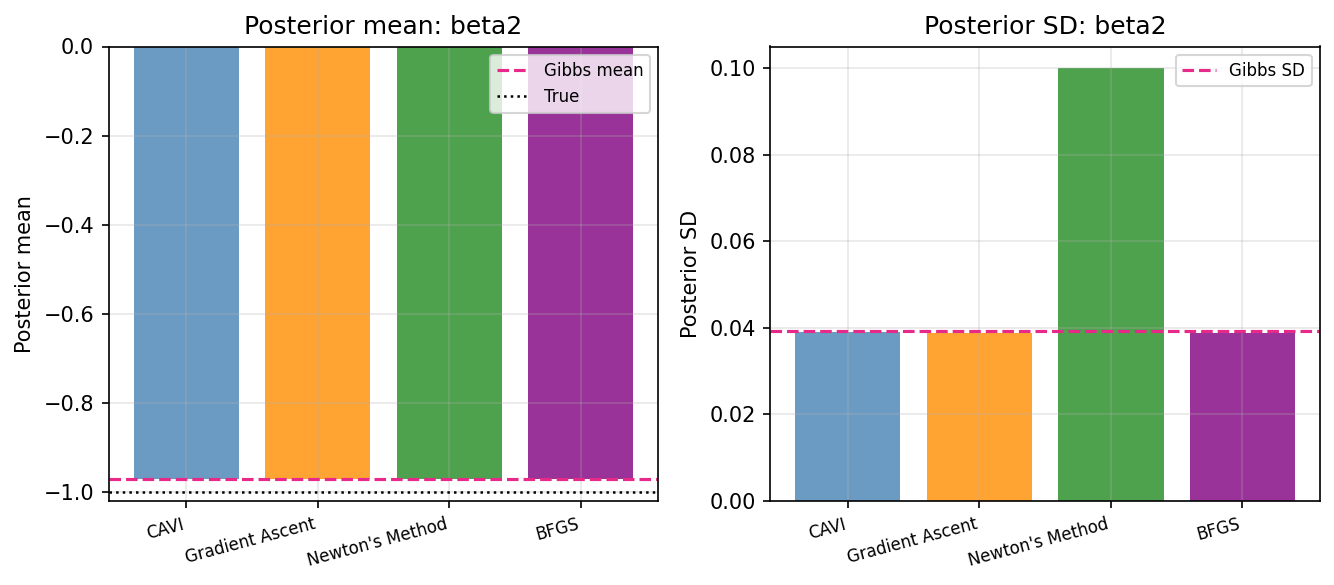

  Saved: quadratic_comparison_tau_e.png


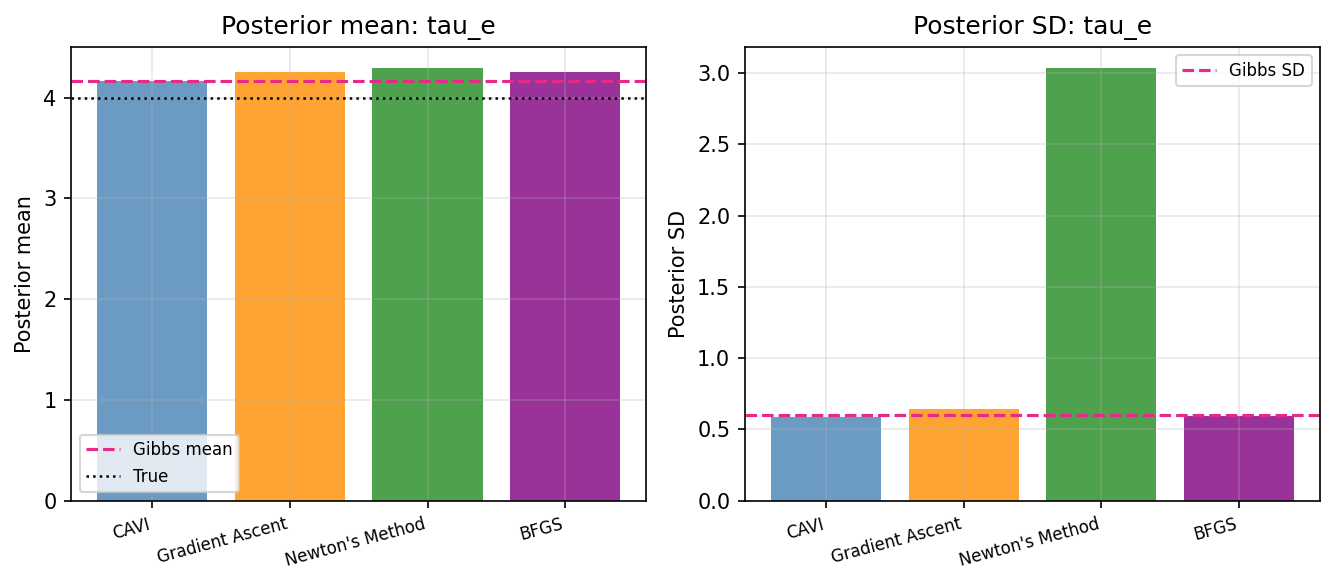

In [20]:
# Per-component posterior mean and SD comparison
for col_idx, pname in enumerate(param_names):
    gibbs_mean = gibbs_means[pname]
    gibbs_std  = gibbs_stds[pname]
    tv         = true_vals[col_idx]

    vb_means_list = []
    vb_stds_list  = []
    for mname, mp in methods.items():
        if col_idx < p:
            vb_means_list.append(float(mp['mu'][col_idx]))
            vb_stds_list.append(float(np.sqrt(mp['Sigma'][col_idx, col_idx])))
        else:
            vb_means_list.append(float(mp['a'] / mp['b']))
            vb_stds_list.append(float(np.sqrt(mp['a']) / mp['b']))

    method_list = list(methods.keys())
    x_bar = np.arange(len(method_list))
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    axes[0].bar(x_bar, vb_means_list,
                color=[method_colors[m] for m in method_list], alpha=0.8)
    axes[0].axhline(gibbs_mean, color='#E7298A', lw=1.5, ls='--', label='Gibbs mean')
    axes[0].axhline(tv, color='black', lw=1.2, ls=':', label='True')
    axes[0].set_xticks(x_bar)
    axes[0].set_xticklabels(method_list, rotation=15, ha='right', fontsize=8)
    axes[0].set_ylabel('Posterior mean')
    axes[0].set_title(f'Posterior mean: {pname}')
    axes[0].legend(fontsize=8)

    axes[1].bar(x_bar, vb_stds_list,
                color=[method_colors[m] for m in method_list], alpha=0.8)
    axes[1].axhline(gibbs_std, color='#E7298A', lw=1.5, ls='--', label='Gibbs SD')
    axes[1].set_xticks(x_bar)
    axes[1].set_xticklabels(method_list, rotation=15, ha='right', fontsize=8)
    axes[1].set_ylabel('Posterior SD')
    axes[1].set_title(f'Posterior SD: {pname}')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    save_fig(fig, f'quadratic_comparison_{pname}.png')
    plt.show()


SD ratios (VB / Gibbs) — values < 1 indicate variance collapse:
  CAVI: beta0=0.992  beta1=0.994  beta2=0.998  tau_e=0.985
  Gradient Ascent: beta0=0.981  beta1=0.984  beta2=0.988  tau_e=1.076
  Newton's Method: beta0=1.641  beta1=1.929  beta2=2.555  tau_e=5.078
  BFGS: beta0=0.982  beta1=0.984  beta2=0.988  tau_e=0.996


  Saved: quadratic_sd_ratios.png


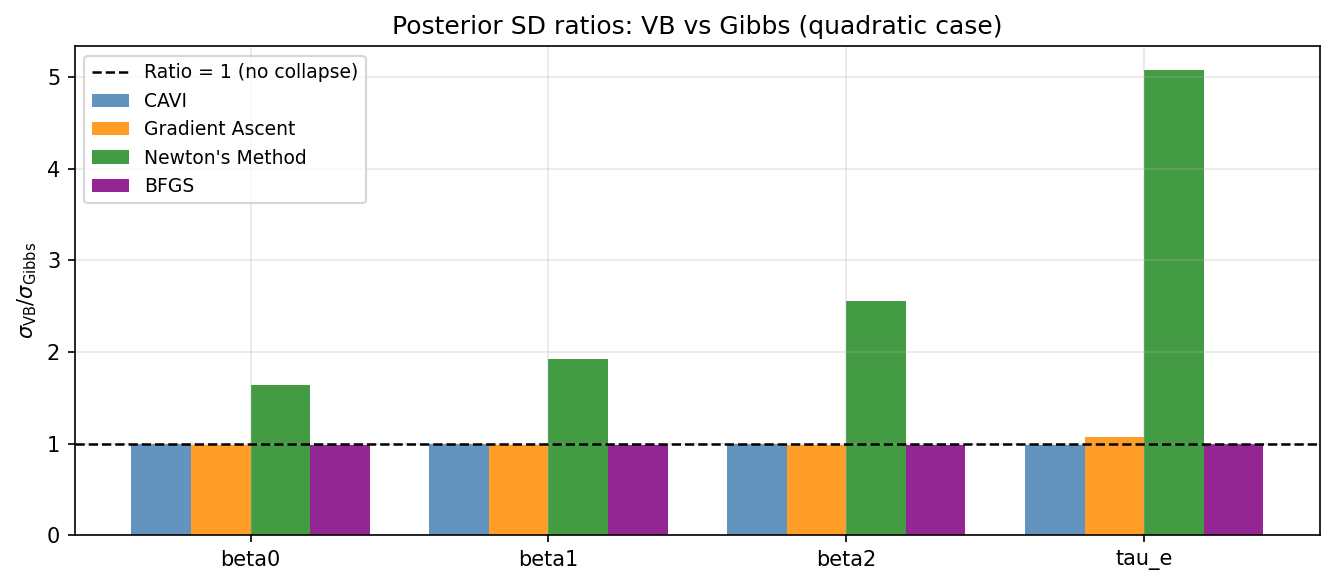

  Saved: quadratic_mean_errors.png


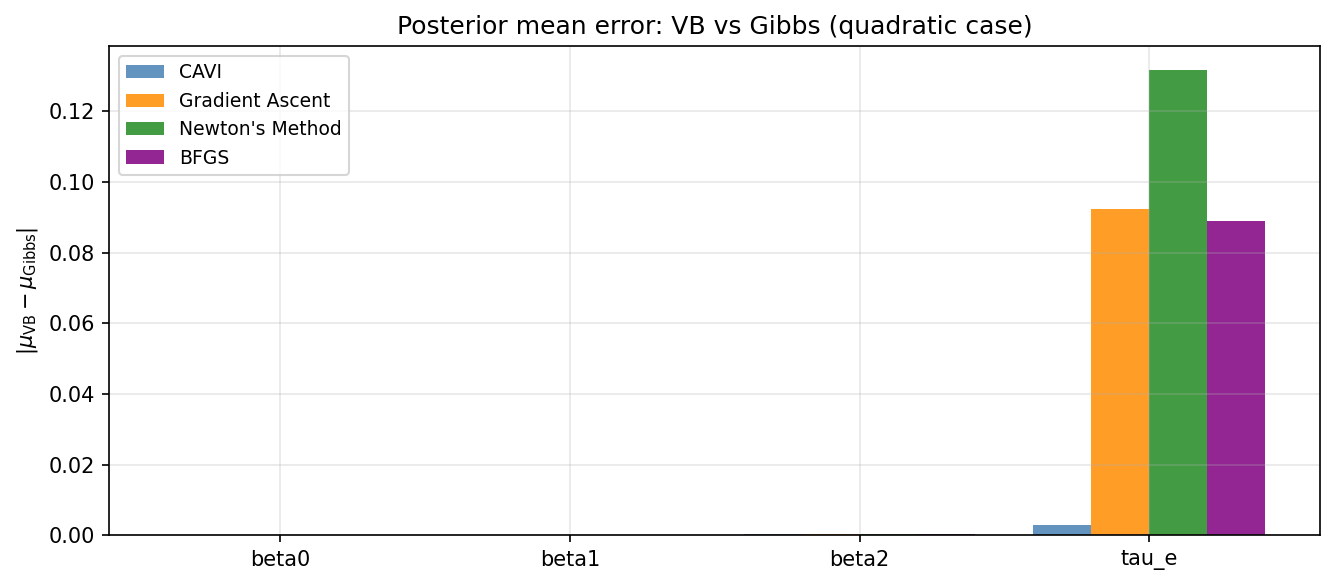

In [21]:
# SD ratios (sigma_VB / sigma_Gibbs) — variance collapse diagnostic
sd_ratios = {}
for mname, mp in methods.items():
    row = {}
    for col_idx, pname in enumerate(param_names):
        if col_idx < p:
            vb_sd = float(np.sqrt(mp['Sigma'][col_idx, col_idx]))
        else:
            vb_sd = float(np.sqrt(mp['a']) / mp['b'])
        row[pname] = vb_sd / gibbs_stds[pname]
    sd_ratios[mname] = row

print('SD ratios (VB / Gibbs) — values < 1 indicate variance collapse:')
for mname, row in sd_ratios.items():
    print(f'  {mname}: ' + '  '.join(f'{k}={v:.3f}' for k, v in row.items()))

x_bar2 = np.arange(len(param_names))
width  = 0.2
fig, ax = plt.subplots(figsize=(9, 4))
for i, (mname, row) in enumerate(sd_ratios.items()):
    vals = [row[pn] for pn in param_names]
    ax.bar(x_bar2 + i * width, vals, width,
           label=mname, color=list(method_colors.values())[i], alpha=0.85)
ax.axhline(1.0, color='black', lw=1.2, ls='--', label='Ratio = 1 (no collapse)')
ax.set_xticks(x_bar2 + 1.5 * width)
ax.set_xticklabels(param_names)
ax.set_ylabel(r'$\sigma_{\mathrm{VB}} / \sigma_{\mathrm{Gibbs}}$')
ax.set_title('Posterior SD ratios: VB vs Gibbs (quadratic case)')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, 'quadratic_sd_ratios.png')
plt.show()

# Posterior mean errors |mu_VB - mu_Gibbs|
mean_errors = {}
for mname, mp in methods.items():
    row = {}
    for col_idx, pname in enumerate(param_names):
        vb_mean = float(mp['mu'][col_idx] if col_idx < p else mp['a'] / mp['b'])
        row[pname] = abs(vb_mean - gibbs_means[pname])
    mean_errors[mname] = row

fig, ax = plt.subplots(figsize=(9, 4))
for i, (mname, row) in enumerate(mean_errors.items()):
    vals = [row[pn] for pn in param_names]
    ax.bar(x_bar2 + i * width, vals, width,
           label=mname, color=list(method_colors.values())[i], alpha=0.85)
ax.set_xticks(x_bar2 + 1.5 * width)
ax.set_xticklabels(param_names)
ax.set_ylabel(r'$|\mu_{\mathrm{VB}} - \mu_{\mathrm{Gibbs}}|$')
ax.set_title('Posterior mean error: VB vs Gibbs (quadratic case)')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, 'quadratic_mean_errors.png')
plt.show()


Saved: quadratic_performance.tex


  Saved: quadratic_timing_comparison.png


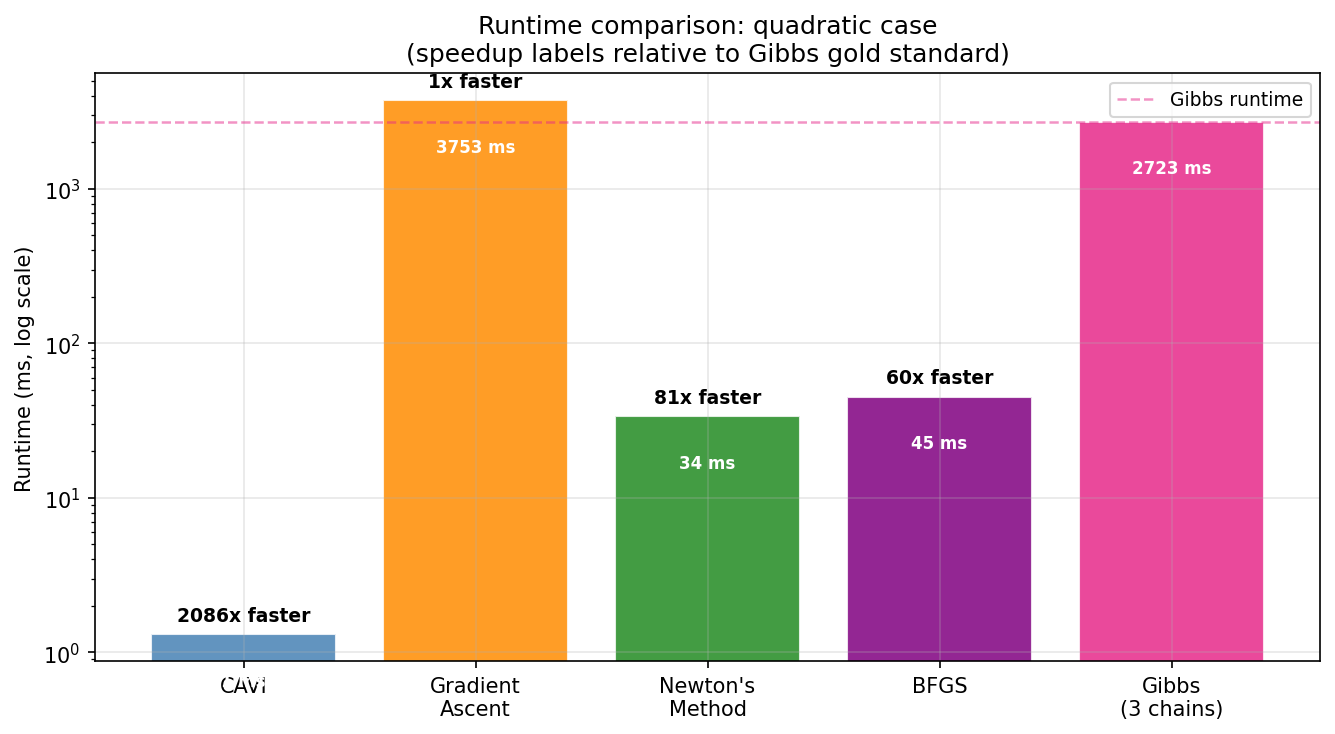

Saved: quadratic_posterior_summary.tex


method,mu_b0,mu_b1,mu_b2,E_tau_e
str,str,str,str,str
"""CAVI""","""0.9714""","""2.0560""","""-0.9718""","""4.1645"""
"""Gradient Ascent""","""0.9713""","""2.0561""","""-0.9719""","""4.2540"""
"""Newton's Method""","""0.9714""","""2.0560""","""-0.9718""","""4.2933"""
"""BFGS""","""0.9714""","""2.0560""","""-0.9718""","""4.2504"""
"""Gibbs (ref)""","""0.9714""","""2.0563""","""-0.9715""","""4.1615"""



All quadratic outputs complete.

Figures saved:
  quadratic_comparison_beta0.png
  quadratic_comparison_beta1.png
  quadratic_comparison_beta2.png
  quadratic_comparison_tau_e.png
  quadratic_data_scatter.png
  quadratic_elbo_convergence.png
  quadratic_elbo_gradient_check.png
  quadratic_elbo_landscape.png
  quadratic_gibbs_acf_beta0.png
  quadratic_gibbs_acf_beta1.png
  quadratic_gibbs_acf_beta2.png
  quadratic_gibbs_acf_tau_e.png
  quadratic_gibbs_rhat.png
  quadratic_gibbs_trace_beta0.png
  quadratic_gibbs_trace_beta1.png
  quadratic_gibbs_trace_beta2.png
  quadratic_gibbs_trace_tau_e.png
  quadratic_gradient_stepsize.png
  quadratic_mean_errors.png
  quadratic_newton_condition.png
  quadratic_sd_ratios.png
  quadratic_timing_comparison.png
  quadratic_vb_gibbs_beta0.png
  quadratic_vb_gibbs_beta1.png
  quadratic_vb_gibbs_beta2.png
  quadratic_vb_gibbs_tau_e.png

Tables saved:
  quadratic_gradient_check.tex
  quadratic_performance.tex
  quadratic_posterior_summary.tex


In [22]:
# --- Table writer ---
def write_tblr(rows, header, path):
    ncols   = len(header)
    colspec = 'l' + 'r' * (ncols - 1)
    lines   = [f'\\begin{{tblr}}{{colspec={{{colspec}}}, hline{{1,2,Z}}={{solid}}}}']
    lines.append('  ' + ' & '.join(header) + ' \\\\')
    for row in rows:
        lines.append('  ' + ' & '.join(str(v) for v in row) + ' \\\\')
    lines.append('\\end{tblr}')
    with open(path, 'w') as f:
        f.write('\n'.join(lines) + '\n')
    print(f'Saved: {path.name}')

runtimes_ms = {
    'CAVI':             t_cavi * 1000,
    'Gradient Ascent':  res_ga['runtime'] * 1000,
    "Newton's Method":  res_newton['runtime'] * 1000,
    'BFGS':             res_bfgs['runtime'] * 1000,
    'Gibbs (3 chains)': t_gibbs * 1000,
}
t_gibbs_ms     = runtimes_ms['Gibbs (3 chains)']
gibbs_converged = all(v < 1.01 for v in rhat.values())

# Table 1: Performance
perf_header = ['Method', 'Iterations', 'Runtime (ms)', 'Speedup vs Gibbs', 'Final ELBO', 'Converged']
perf_rows = [
    ['CAVI',
     str(res_cavi['iterations']),
     f'{runtimes_ms["CAVI"]:.1f}',
     f'{t_gibbs_ms / runtimes_ms["CAVI"]:.0f}x',
     f'{float(cavi_elbo[-1]):.3f}', 'Yes'],
    ['Gradient Ascent',
     str(res_ga['iterations']),
     f'{runtimes_ms["Gradient Ascent"]:.1f}',
     f'{t_gibbs_ms / runtimes_ms["Gradient Ascent"]:.0f}x',
     f'{float(res_ga["elbo_history"][-1]):.3f}', 'Yes'],
    ["Newton's Method",
     str(res_newton['iterations']),
     f'{runtimes_ms["Newton\'s Method"]:.1f}',
     f'{t_gibbs_ms / runtimes_ms["Newton\'s Method"]:.1f}x',
     f'{float(res_newton["elbo_history"][-1]):.3f}', 'Yes'],
    ['BFGS',
     str(res_bfgs['iterations']),
     f'{runtimes_ms["BFGS"]:.1f}',
     f'{t_gibbs_ms / runtimes_ms["BFGS"]:.0f}x',
     f'{float(res_bfgs["elbo_history"][-1]):.3f}', 'Yes'],
    ['Gibbs (3 chains)', '3 x 5000', f'{t_gibbs_ms:.1f}', '1x (reference)',
     'N/A (MCMC)', 'Yes' if gibbs_converged else 'No'],
]
write_tblr(perf_rows, perf_header, TABLES / 'quadratic_performance.tex')

# Timing bar chart
method_labels_plot = ['CAVI', 'Gradient\nAscent', "Newton's\nMethod", 'BFGS', 'Gibbs\n(3 chains)']
method_keys_list   = ['CAVI', 'Gradient Ascent', "Newton's Method", 'BFGS', 'Gibbs (3 chains)']
timing_vals  = [runtimes_ms[k] for k in method_keys_list]
timing_cols  = ['steelblue', 'darkorange', 'forestgreen', 'purple', '#E7298A']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(method_labels_plot, timing_vals, color=timing_cols, alpha=0.85, edgecolor='white')
for bar, key in zip(bars, method_keys_list):
    t_k = runtimes_ms[key]
    if key != 'Gibbs (3 chains)':
        speedup = t_gibbs_ms / t_k
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
                f'{speedup:.0f}x faster',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
            f'{t_k:.0f} ms',
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')
ax.set_yscale('log')
ax.set_ylabel('Runtime (ms, log scale)')
ax.set_title('Runtime comparison: quadratic case\n(speedup labels relative to Gibbs gold standard)')
ax.axhline(t_gibbs_ms, color='#E7298A', lw=1.2, ls='--', alpha=0.5, label='Gibbs runtime')
ax.legend(fontsize=9)
plt.tight_layout()
save_fig(fig, 'quadratic_timing_comparison.png')
plt.show()

# Table 2: Posterior summary
post_header = [
    'Method',
    r'$\mu_{\beta_0}$', r'$\mu_{\beta_1}$', r'$\mu_{\beta_2}$',
    r'$\mathrm{E}[\tau_e]$',
    r'SD $\beta_0$', r'SD $\beta_1$', r'SD $\beta_2$', r'SD $\tau_e$',
]
post_rows = []
for mname, mp in methods.items():
    mu_row  = [f'{float(mp["mu"][0]):.4f}', f'{float(mp["mu"][1]):.4f}',
               f'{float(mp["mu"][2]):.4f}', f'{float(mp["a"]/mp["b"]):.4f}']
    sdr_row = [f'{sd_ratios[mname][pn]:.3f}' for pn in param_names]
    post_rows.append([mname] + mu_row + sdr_row)
gibbs_row = [
    'Gibbs (ref)',
    f'{gibbs_means["beta0"]:.4f}', f'{gibbs_means["beta1"]:.4f}',
    f'{gibbs_means["beta2"]:.4f}', f'{gibbs_means["tau_e"]:.4f}',
    '1.000', '1.000', '1.000', '1.000',
]
post_rows.append(gibbs_row)
write_tblr(post_rows, post_header, TABLES / 'quadratic_posterior_summary.tex')

display(pl.DataFrame({
    'method':  [r[0] for r in post_rows],
    'mu_b0':   [r[1] for r in post_rows],
    'mu_b1':   [r[2] for r in post_rows],
    'mu_b2':   [r[3] for r in post_rows],
    'E_tau_e': [r[4] for r in post_rows],
}))

print('\nAll quadratic outputs complete.')
print('\nFigures saved:')
for f in sorted(FIGS.glob('quadratic_*.png')):
    print(f'  {f.name}')
print('\nTables saved:')
for f in sorted(TABLES.glob('quadratic_*.tex')):
    print(f'  {f.name}')
